# ExplainPhish: HTML Phishing Detection - Data Overview
This notebook provides an in-depth **Data Overview** and exploratory data analysis for the **HTML** modality of the **ExplainPhish** project.

The dataset is derived from the **CIC-Trap4Phish2025** benchmark, consisting of static features extracted from legitimate (benign) and phishing HTML documents. No active macros, scripts, or network requests are executed during this analysis; detection relies entirely on safe, static structural, lexical, and script characteristics.

---

## Contents
- [1. Setup & Environment](#scrollTo=setup)
  - [1.1 Import Libraries](#scrollTo=import_libraries)
  - [1.2 Adaptive Path Resolution](#scrollTo=path_config)
- [2. Loading the Data & Data Overview](#scrollTo=loading_data)
  - [2.1 Raw Loading](#scrollTo=raw_loading)
  - [2.2 Data Cleaning & Artifact Removal](#scrollTo=data_cleaning)
  - [2.3 Feature Inventory & Data Types](#scrollTo=feature_inventory)
  - [2.4 Missing Value Analysis](#scrollTo=missing_values)
  - [2.5 Summary & Descriptive Statistics](#scrollTo=descriptive_stats)
  - [2.6 Target Class Balance Analysis](#scrollTo=class_balance)
  - [2.7 HTML Feature Definitions & Threat Relevance](#scrollTo=feature_definitions)
  - [2.8 Feature Distribution Comparison (Benign vs. Phishing)](#scrollTo=feature_dist)
- [3. Dataset Preparation](#scrollTo=dataset_prep)
  - [3.1 Feature Matrix (X) and Target Vector (y)](#scrollTo=xy_split)
  - [3.2 Stratified 60/40 Train/Test Split](#scrollTo=train_test_split)

<a name="setup"></a>
## 1. Setup & Environment

In this section, we set up the environment, import standard data science and visualization libraries with consistent visual themes, and locate the dataset file.

<a name="import_libraries"></a>
### 1.1 Import Libraries
We import `pandas` for tabular data manipulation, `numpy` for numerical calculations, `matplotlib` and `seaborn` for visualizations, and `pathlib` for flexible cross-platform path resolution.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme!")

Environment configured successfully with consistent visual theme!


<a name="path_config"></a>
### 1.2 Adaptive Path Resolution
To ensure this notebook runs seamlessly whether executed locally in VS Code / Jupyter, from the repository root, or in Google Colab (with or without Google Drive mounted), we define adaptive path resolution for `HTML_Top13_Features.csv`.

In [2]:
# Adaptive path detection for local environments and Google Colab
candidates = [
    Path("data/html/HTML_Top13_Features.csv"),
    Path("googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("../data/html/HTML_Top13_Features.csv"),
    Path("../googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("../../googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/html/HTML_Top13_Features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("/content/HTML_Top13_Features.csv")
]

dataset_path = None
for p in candidates:
    if p.exists():
        dataset_path = p
        break

if dataset_path is not None:
    print(f"Dataset located successfully at:\n{dataset_path.resolve()}")
else:
    raise FileNotFoundError(
        "Could not automatically locate 'HTML_Top13_Features.csv'. "
        "Please upload the file to Google Colab or verify the directory path."
    )

Dataset located successfully at:
D:\codingProject\ExplainPhish\googleCollab\data\html\HTML_Top13_Features.csv


<a name="loading_data"></a>
## 2. Loading the Data & Data Overview

In this section, we load the raw HTML feature table, sanitize export artifacts, examine dataset dimensions, inspect column types, verify complete data integrity, evaluate summary statistics, evaluate class balance, and review the security relevance of each feature.

<a name="raw_loading"></a>
### 2.1 Raw Loading
We load the raw CSV file into a `pandas.DataFrame` and preview the first 5 records.

In [3]:
# Load raw dataset
raw_df = pd.read_csv(dataset_path)

print(f"Raw Dataset Dimensions: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)

Raw Dataset Dimensions: 19,997 rows x 27 columns


,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,sample_09001.html,756,475,0.4769,5.0729,0,11,0.1527,4.9064,1,57,15762,39,109,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sample_09002.html,287,82,0.3566,5.2020,0,3,0.1795,4.6251,21,8,2543,27,130,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sample_09003.html,667,406,0.3902,5.1642,1,10,0.1498,4.2204,9,80,7163,26,333,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sample_09004.html,1204,321,0.5348,5.6712,0,33,0.0257,5.6267,17,74,268250,2,1013,0,NaN,NaN,NaN,9998.0000,NaN,NaN,NaN,NaN,9998.0000,NaN,NaN,NaN
4,sample_09005.html,2606,665,0.4416,5.1366,5,8,0.1301,5.4630,8,243,7666,8,924,0,NaN,NaN,NaN,10000.0000,NaN,19998.0000,9999.0000,NaN,10000.0000,NaN,19998.0000,11998.8000


<a name="data_cleaning"></a>
### 2.2 Data Cleaning & Artifact Removal
Notice that the raw CSV file contains trailing `Unnamed: 15` through `Unnamed: 26` columns. These are empty artifacts caused by trailing delimiters during export. We identify and drop these empty columns, reducing the table to the sample identifier (`file_name`), 13 security features, and target label (`label`).

In [4]:
# Identify trailing artifact columns
unnamed_cols = [c for c in raw_df.columns if "unnamed" in c.lower()]
print(f"Identified {len(unnamed_cols)} trailing artifact columns to drop: {unnamed_cols}")

# Drop artifact columns to produce clean dataframe
df = raw_df.drop(columns=unnamed_cols).copy()

print(f"Cleaned Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(5)

Identified 12 trailing artifact columns to drop: ['Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26']
Cleaned Dataset Dimensions: 19,997 rows x 15 columns


,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label
0,sample_09001.html,756,475,0.4769,5.0729,0,11,0.1527,4.9064,1,57,15762,39,109,0
1,sample_09002.html,287,82,0.3566,5.2020,0,3,0.1795,4.6251,21,8,2543,27,130,0
2,sample_09003.html,667,406,0.3902,5.1642,1,10,0.1498,4.2204,9,80,7163,26,333,0
3,sample_09004.html,1204,321,0.5348,5.6712,0,33,0.0257,5.6267,17,74,268250,2,1013,0
4,sample_09005.html,2606,665,0.4416,5.1366,5,8,0.1301,5.4630,8,243,7666,8,924,0


<a name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Let's inspect the data types, non-null counts, and memory footprint of the cleaned dataset.

In [5]:
# Inspect column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19997 entries, 0 to 19996
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   file_name                19997 non-null  str    
 1   url_punct_char_count     19997 non-null  int64  
 2   tag_count                19997 non-null  int64  
 3   whitespace_ratio         19997 non-null  float64
 4   entropy                  19997 non-null  float64
 5   form_count               19997 non-null  int64  
 6   embedded_js_count        19997 non-null  int64  
 7   html_whitespace_ratio    19997 non-null  float64
 8   script_entropy           19997 non-null  float64
 9   min_link_length          19997 non-null  int64  
 10  external_link_count      19997 non-null  int64  
 11  total_script_characters  19997 non-null  int64  
 12  internal_link_count      19997 non-null  int64  
 13  url_digit_count          19997 non-null  int64  
 14  label                    19997 no

<a name="missing_values"></a>
### 2.4 Missing Value Analysis
Missing values can impair machine learning estimators. Let's inspect the dataset to ensure all feature values and labels are fully populated.

In [6]:
# Missing values inspection
missing_counts = df.isnull().sum()
missing_pcts = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage (%)": missing_pcts
})

missing_cols = missing_summary[missing_summary["Missing Count"] > 0]
if len(missing_cols) == 0:
    print(f"No missing values found across all {df.shape[1]} columns! Dataset is 100% complete.")
else:
    print(f"Found {len(missing_cols)} columns with missing values:")
    display(missing_cols)

No missing values found across all 15 columns! Dataset is 100% complete.


<a name="descriptive_stats"></a>
### 2.5 Summary & Descriptive Statistics
Let's analyze the statistical distribution (mean, standard deviation, min, 25th percentile, median, 75th percentile, and max) for all 13 numeric HTML features.

In [7]:
# Extract numeric feature columns (excluding file identifier and target label)
feature_cols = [c for c in df.columns if c not in ["file_name", "label"]]

# Compute descriptive statistics
stats_df = df[feature_cols].describe().T
stats_df["median"] = df[feature_cols].median()
stats_df = stats_df[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]

stats_df

,count,mean,std,min,25%,median,75%,max
url_punct_char_count,19997.0000,884.2841,3466.0368,0.0000,47.0000,265.0000,1037.0000,283826.0000
tag_count,19997.0000,483.9136,984.3284,3.0000,57.0000,182.0000,600.0000,43591.0000
whitespace_ratio,19997.0000,0.3716,0.1644,0.0000,0.2863,0.3960,0.4873,0.8544
entropy,19997.0000,5.1664,0.3877,0.9144,4.9917,5.1790,5.3541,7.8747
form_count,19997.0000,1.3196,2.8331,0.0000,0.0000,1.0000,2.0000,189.0000
embedded_js_count,19997.0000,7.2617,12.3293,0.0000,1.0000,3.0000,9.0000,333.0000
html_whitespace_ratio,19997.0000,0.1183,0.0762,0.0000,0.0706,0.1082,0.1492,0.8301
script_entropy,19997.0000,4.1169,2.0508,0.0000,4.3563,5.0423,5.3660,6.2742
min_link_length,19997.0000,20.7234,686.9872,0.0000,1.0000,1.0000,11.0000,77698.0000
external_link_count,19997.0000,55.1496,119.7534,0.0000,1.0000,16.0000,66.0000,5550.0000


**Key Statistical Insights**:
- **Tag Count (`tag_count`)**: Ranges from 3 to 43,591 tags, with a median of 302 tags. The large difference between median (302) and max (43,591) reflects the wide variation in HTML document size between minimal landing pages and complex enterprise portals.
- **Script Length (`total_script_characters`)**: Medians at 4,777 characters, with some pages having 0 script characters (plain HTML) and complex pages exceeding 2.5 million characters.
- **Shannon Entropy (`entropy` & `script_entropy`)**: HTML entropy has an average of ~5.20 with a standard deviation of 0.36, indicating fairly tight distribution around typical compressed text entropy. Script entropy averages 4.48.

<a name="class_balance"></a>
### 2.6 Target Class Balance Analysis
In cybersecurity and phishing classification, heavily skewed datasets (class imbalance) can lead to models that deceptively show high accuracy while missing threats. Let's analyze the distribution of our target variable `label`:
- **0**: Benign / Legitimate HTML file
- **1**: Phishing / Malicious HTML file

,Class,Sample Count,Proportion (%)
0,Phishing (1),9999,50.0025
1,Benign (0),9998,49.9975


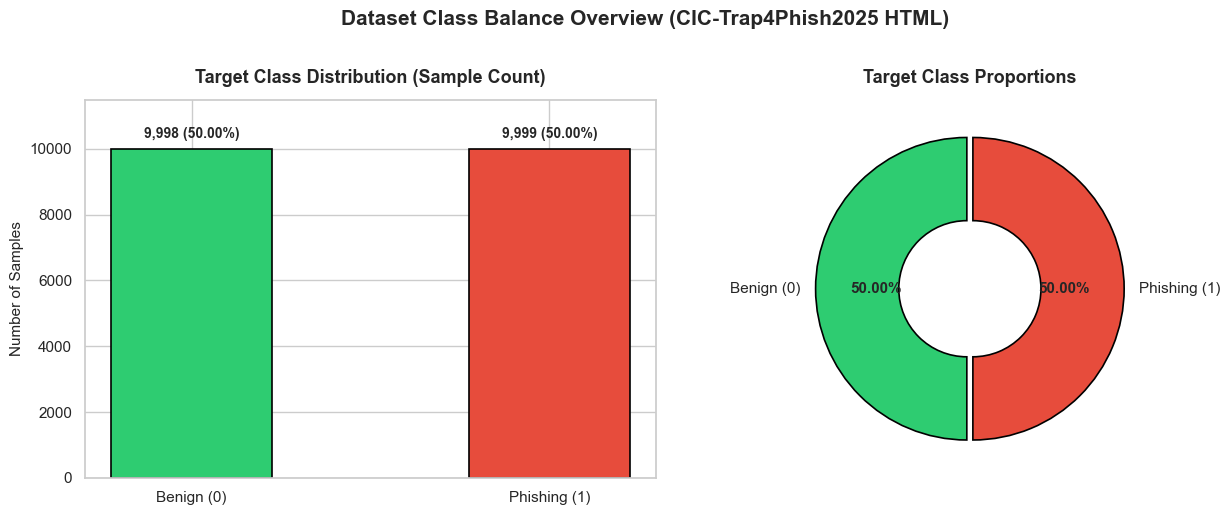

In [8]:
# Target class counts and percentages
counts = df["label"].value_counts()
proportions = df["label"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "Class": ["Phishing (1)", "Benign (0)"] if counts.index[0] == 1 else ["Benign (0)", "Phishing (1)"],
    "Sample Count": [counts[1], counts[0]],
    "Proportion (%)": [proportions[1], proportions[0]]
})

display(class_summary)

# Side-by-side visualization: Count bar chart and proportion donut chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Bar chart
colors = ["#2ecc71", "#e74c3c"]
bars = ax1.bar(
    ["Benign (0)", "Phishing (1)"], 
    [counts[0], counts[1]], 
    color=colors, 
    width=0.45, 
    edgecolor="black", 
    linewidth=1.2
)
ax1.set_title("Target Class Distribution (Sample Count)", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Number of Samples", fontsize=11)
ax1.set_ylim(0, max(counts) * 1.15)
for bar in bars:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, 
        yval + 250, 
        f"{int(yval):,} ({yval / len(df) * 100:.2f}%)", 
        ha="center", 
        va="bottom", 
        fontweight="bold", 
        fontsize=10
    )

# 2. Donut / Pie chart
wedges, texts, autotexts = ax2.pie(
    [counts[0], counts[1]],
    labels=["Benign (0)", "Phishing (1)"],
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    explode=(0.02, 0.02),
    wedgeprops=dict(width=0.55, edgecolor="black", linewidth=1.2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax2.set_title("Target Class Proportions", fontsize=13, fontweight="bold", pad=12)

plt.suptitle("Dataset Class Balance Overview (CIC-Trap4Phish2025 HTML)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

> [!NOTE]
> **Observation**: The dataset exhibits virtually **perfect 50/50 balance** (9,998 Benign vs. 9,999 Phishing samples, 49.998% vs 50.002%). 
> Consequently, artificial resampling methods (such as SMOTE or random undersampling) are **not required**, and metrics like Accuracy, ROC-AUC, and F1-score can be evaluated reliably.

<a name="feature_definitions"></a>
### 2.7 HTML Feature Definitions & Threat Relevance

The 13 extracted features capture structural, lexical, script, and URL characteristics designed to separate phishing artifacts from benign web content without requiring code execution:

| # | Feature Name | Data Type | Description & Security Relevance |
| :--- | :--- | :--- | :--- |
| 1 | `url_punct_char_count` | Integer | Total punctuation characters (`/`, `.`, `-`, `_`, `=`, `?`, `&`, `;`) across all extracted URLs. Phishing links often employ nested redirects, base64 query tokens, or deceptive subdomains with heavy punctuation. |
| 2 | `tag_count` | Integer | Total count of HTML tags in the DOM. Legitimate portals have rich DOM structures (median ~514 tags), whereas phishing templates tend to be minimal landing pages (median ~91 tags) focused only on the credential trap. |
| 3 | `whitespace_ratio` | Float | Ratio of whitespace in extracted text. Phishers often introduce abnormal whitespace padding or zero-width spaces to bypass simple keyword filters. |
| 4 | `entropy` | Float | Shannon entropy of the overall raw HTML document. Measures informational randomness; obfuscated, packed, or encoded HTML shows distinctive entropy signatures. |
| 5 | `form_count` | Integer | Total `<form>` elements. Phishing attacks almost universally revolve around harvesting credentials (usernames, passwords, MFA codes, credit cards) through web forms. |
| 6 | `embedded_js_count` | Integer | Number of inline `<script>` blocks (scripts without an external `src`). Inline scripts are commonly used in phishing kits to perform browser fingerprinting or credential exfiltration without external domain lookups. |
| 7 | `html_whitespace_ratio` | Float | Ratio of whitespace across the full HTML source code. Reflects formatting, code minification, or packing patterns. |
| 8 | `script_entropy` | Float | Shannon entropy calculated specifically over JavaScript code blocks. Packed, obfuscated, or encrypted JavaScript payloads produce noticeably higher entropy. |
| 9 | `min_link_length` | Integer | Character length of the shortest hyperlink in the page. Decoy templates or broken phishing clones frequently contain single-character links (`#`, `/`). |
| 10 | `external_link_count` | Integer | Number of hyperlinks referencing external domains. Legitimate sites have diverse internal/external navigation, while phishing kits restrict external outbound links to keep the victim focused on the capture form. |
| 11 | `total_script_characters`| Integer | Cumulative character count of all JavaScript blocks. Distinguishes rich modern web applications from compact phishing capture scripts. |
| 12 | `internal_link_count` | Integer | Number of relative or same-domain hyperlinks. Legitimate sites feature extensive site navigation (median ~32 links), while phishing sites rarely implement functional internal links (median ~6 links). |
| 13 | `url_digit_count` | Integer | Total numeric digits across all hyperlinks. Phishing URLs frequently incorporate numeric IP addresses, hexadecimal identifiers, or randomized session tokens. |

<a name="feature_dist"></a>
### 2.8 Feature Distribution Comparison (Benign vs. Phishing)
Let's compare the distributions of key features across the Benign (`0`) and Phishing (`1`) classes using boxplots and a comparative median/mean table.

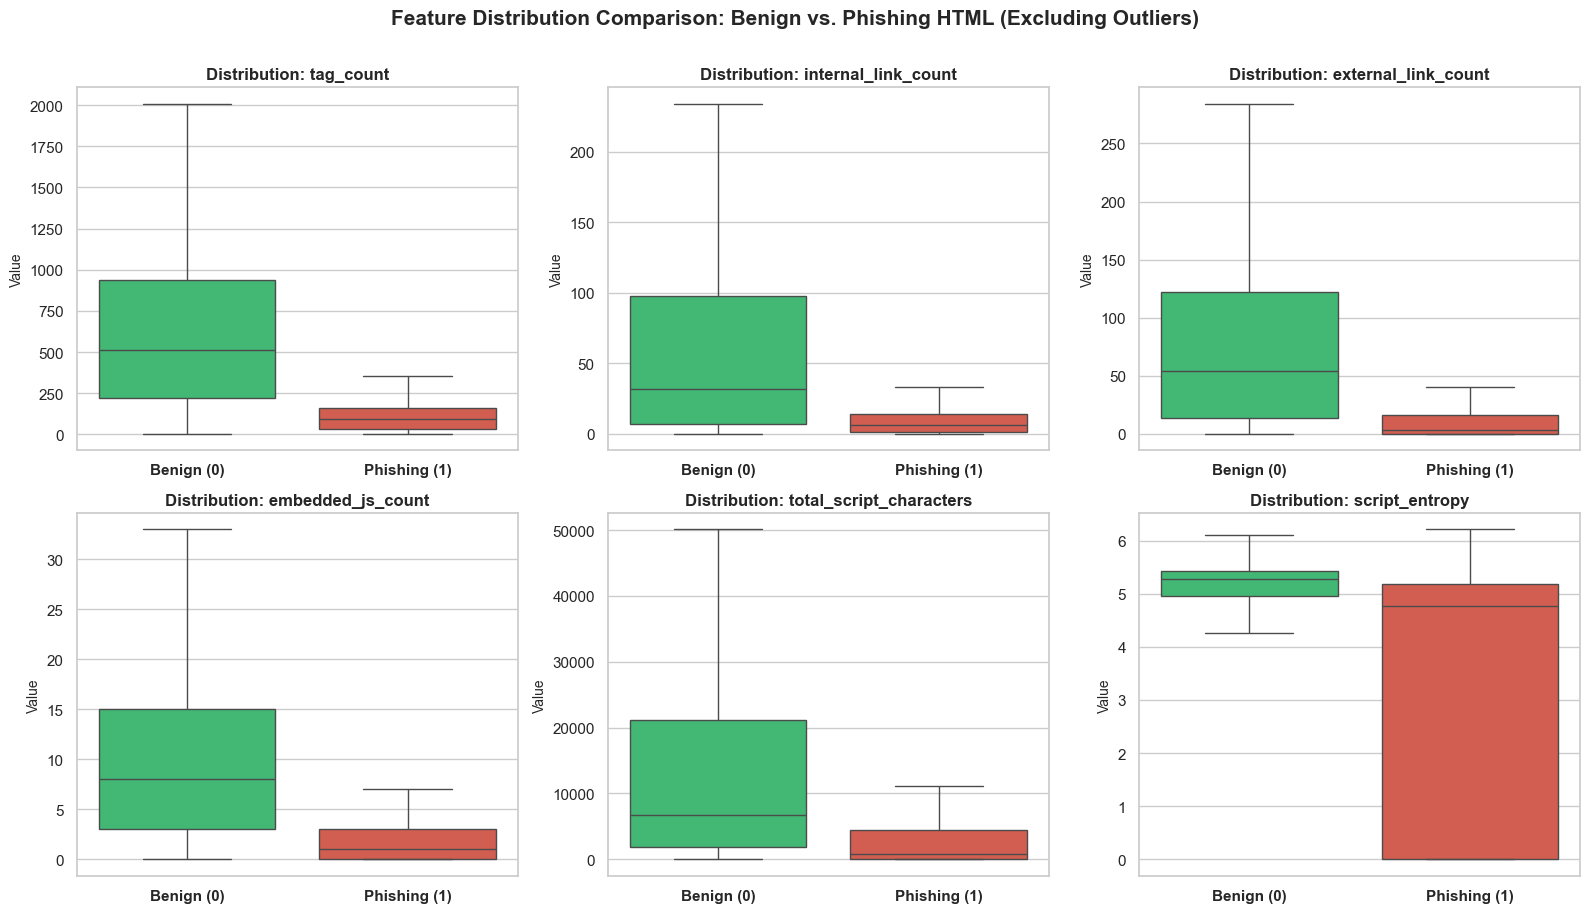

In [9]:
# Select 6 distinguishing features for visual comparison
dist_features = [
    "tag_count", 
    "internal_link_count", 
    "external_link_count", 
    "embedded_js_count", 
    "total_script_characters", 
    "script_entropy"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(dist_features):
    ax = axes[i]
    sns.boxplot(
        data=df,
        x="label",
        y=col,
        ax=ax,
        palette=["#2ecc71", "#e74c3c"],
        hue="label",
        legend=False,
        showfliers=False  # Hide extreme outliers for clearer quantile visibility
    )
    # Set fixed tick positions and labels in a single call (eliminates Matplotlib UserWarnings)
    ax.set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"], fontweight="bold")
    ax.set_title(f"Distribution: {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Value", fontsize=10)

plt.suptitle("Feature Distribution Comparison: Benign vs. Phishing HTML (Excluding Outliers)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Summary comparison table of medians and means between Benign and Phishing HTML files:

In [10]:
# Comparative statistics by class
comp_table = df.groupby("label")[feature_cols].agg(["median", "mean"]).T.unstack(level=1)
comp_table.columns = [
    "Benign Median", "Benign Mean", 
    "Phishing Median", "Phishing Mean"
]
comp_table = comp_table[["Benign Median", "Phishing Median", "Benign Mean", "Phishing Mean"]]
comp_table

,Benign Median,Phishing Median,Benign Mean,Phishing Mean
url_punct_char_count,880.0000,90.0000,1392.7169,375.9021
tag_count,514.0000,91.0000,791.3749,176.4831
whitespace_ratio,0.4277,0.3712,0.4154,0.3278
entropy,5.1733,5.1874,5.1729,5.1599
form_count,1.0000,1.0000,1.5368,1.1025
embedded_js_count,8.0000,1.0000,11.5208,3.0030
html_whitespace_ratio,0.1182,0.0956,0.1235,0.1131
script_entropy,5.2723,4.7650,4.7565,3.4775
min_link_length,1.0000,3.0000,11.1427,30.3030
external_link_count,54.0000,3.0000,92.3389,17.9641


<a name="dataset_prep"></a>
## 3. Dataset Preparation

Now that the data overview is complete, we separate the data into the feature matrix `X` and target vector `y`, dropping the sample identifier `file_name`. We then perform a **stratified 60/40 train/test split** aligned with the ExplainPhish `train.py` training pipeline methodology (`RANDOM_STATE=42`).

<a name="xy_split"></a>
### 3.1 Feature Matrix (X) and Target Vector (y)
We isolate the 13 numerical features and the binary target label.

In [11]:
# Define features and target
X = df[feature_cols].copy()
y = df["label"].copy()

print(f"Feature Matrix (X): {X.shape[0]:,} samples x {X.shape[1]} features")
print(f"Target Vector  (y): {y.shape[0]:,} labels")
print(f"Target Distribution: Benign (0) = {(y == 0).sum():,}, Phishing (1) = {(y == 1).sum():,}")

Feature Matrix (X): 19,997 samples x 13 features
Target Vector  (y): 19,997 labels
Target Distribution: Benign (0) = 9,998, Phishing (1) = 9,999


<a name="train_test_split"></a>
### 3.2 Stratified Train / Test Split (60% Train / 40% Test)
We split the dataset into 60% training and 40% hold-out test set using stratified sampling to preserve the 50/50 class balance.
The test set remains untouched during feature selection and model cross-validation, aligned with `train.py`.

In [12]:
from sklearn.model_selection import train_test_split

# Stratified 60/40 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.40, 
    stratify=y, 
    random_state=42
)

split_summary = pd.DataFrame({
    "Subset": ["Train (60%)", "Test (40%)", "Full Dataset"],
    "Total Samples": [len(y_train), len(y_test), len(y)],
    "Benign (0)": [(y_train == 0).sum(), (y_test == 0).sum(), (y == 0).sum()],
    "Phishing (1)": [(y_train == 1).sum(), (y_test == 1).sum(), (y == 1).sum()],
    "Phishing Rate (%)": [
        (y_train == 1).mean() * 100, 
        (y_test == 1).mean() * 100, 
        (y == 1).mean() * 100
    ]
})

print("Train / Test Split Summary:")
display(split_summary)
print("\nHTML Data Overview is complete and ready for Model Training & Explainability!")

Train / Test Split Summary:


,Subset,Total Samples,Benign (0),Phishing (1),Phishing Rate (%)
0,Train (60%),11998,5999,5999,50.0000
1,Test (40%),7999,3999,4000,50.0063
2,Full Dataset,19997,9998,9999,50.0025



HTML Data Overview is complete and ready for Model Training & Explainability!
